Name: Eric Baah
Course: MAT 443
Homework 7
Date: 11/03/2024

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from ISLP import load_data
import warnings
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from ISLP.models import (ModelSpec as MS, summarize, poly)
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
from sklearn.linear_model import LinearRegression
import seaborn as sns
from xgboost import XGBRegressor as XGB
from lightgbm import LGBMRegressor as LGBMR

### Question 8.5

The ten estimates of $ P(\text{Class is Red} | X) $ are:
$
0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75
$

$\textbf{Approach 1: Majority Vote}$

In the majority vote approach, we classify each estimate as "Red" if $ P(\text{Class is Red} | X) > 0.5 $; otherwise, we classify it as "Green."

- Estimates $ 0.1, 0.15, 0.2, 0.2 $ are classified as "Green."
- Estimates $ 0.55, 0.6, 0.6, 0.65, 0.7, 0.75 $ are classified as "Red."

Counting each class:
- "Green" appears $ 4 $ times.
- "Red" appears $ 6 $ times.

Since "Red" has the majority, the final classification under the majority vote approach is:
$\text{Red} $



$\textbf{Approach 2: Average Probability}$

In the average probability approach, we calculate the mean of all 10 estimates:

$
\text{Average} = \frac{0.1 + 0.15 + 0.2 + 0.2 + 0.55 + 0.6 + 0.6 + 0.65 + 0.7 + 0.75}{10} = \frac{4.5}{10} = 0.45
$

Since the average probability $ 0.45 \leq 0.5 $, the final classification under the average probability approach is:
$
\text{Green}
$


### Question 8.8

In [17]:
# Load the dataset
data=load_data("Carseats")

# Assuming 'data' is your DataFrame
data = pd.get_dummies(data, drop_first=True)

In [18]:
# Part (a)

# Split data into features (X) and target (y)
X = data.drop(columns=['Sales'])  # assuming 'Sales' is the target variable
y = data['Sales']
print(data.head(5))
# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


   Sales  CompPrice  Income  Advertising  Population  Price  Age  Education  \
0   9.50        138      73           11         276    120   42         17   
1  11.22        111      48           16         260     83   65         10   
2  10.06        113      35           10         269     80   59         12   
3   7.40        117     100            4         466     97   55         14   
4   4.15        141      64            3         340    128   38         13   

   ShelveLoc_Good  ShelveLoc_Medium  Urban_Yes  US_Yes  
0           False             False       True    True  
1            True             False       True    True  
2           False              True       True    True  
3           False              True       True    True  
4           False             False       True   False  


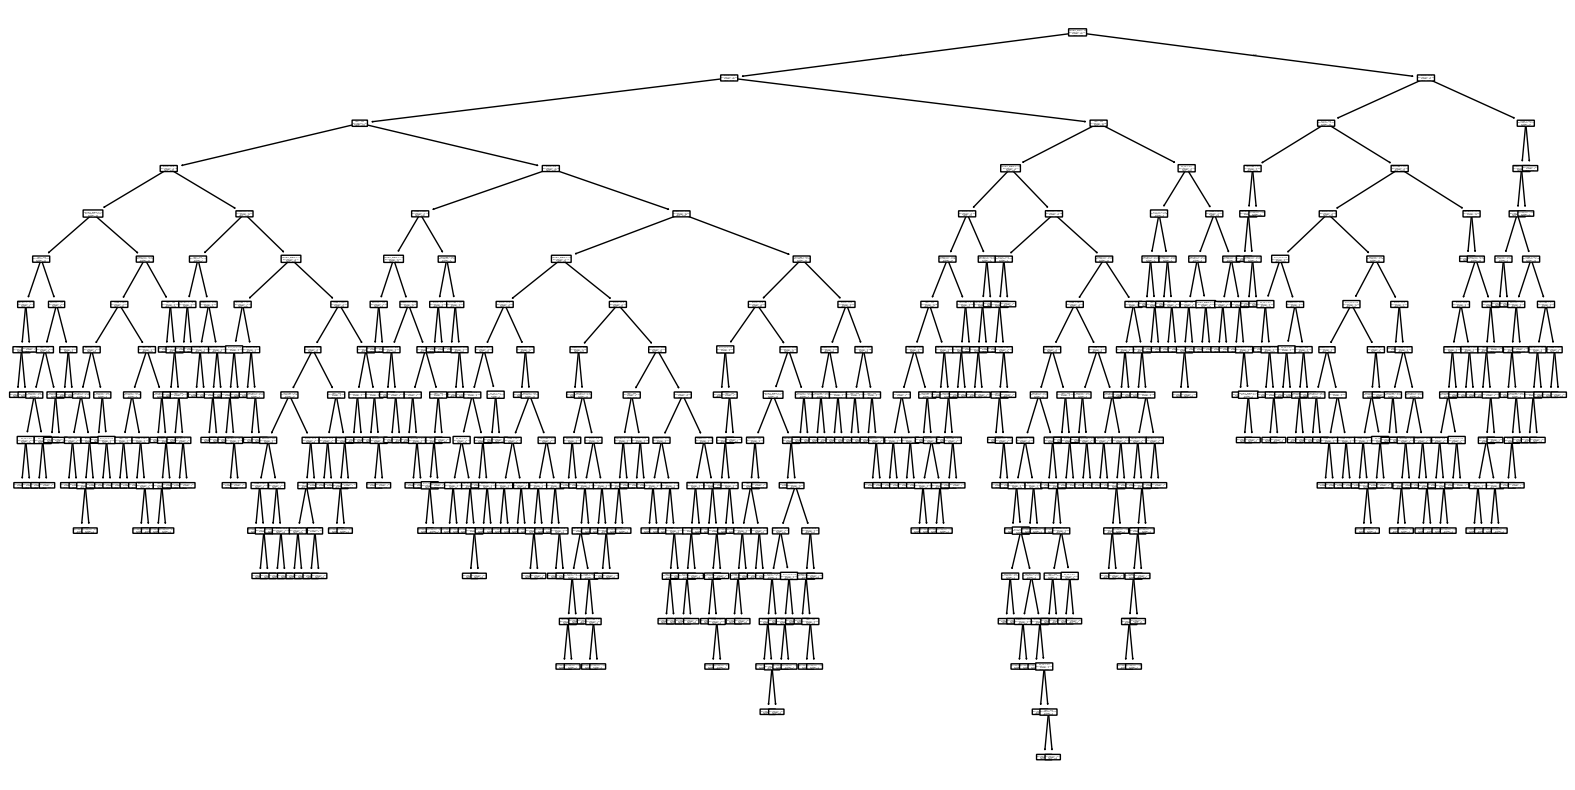

Test MSE for Regression Tree: 6.179


In [19]:
# Part (b)

# Initialize and fit the regression tree model
reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 10))
plot_tree(reg_tree, feature_names=X.columns, rounded=True)
plt.show()

# Predict on the test set and calculate the MSE
y_pred_tree = reg_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"Test MSE for Regression Tree: {mse_tree:.3f}")


The above tree is so complex and it is difficult to see the results and interpret. If we restrict the maximum depth to 3, we have the following three.

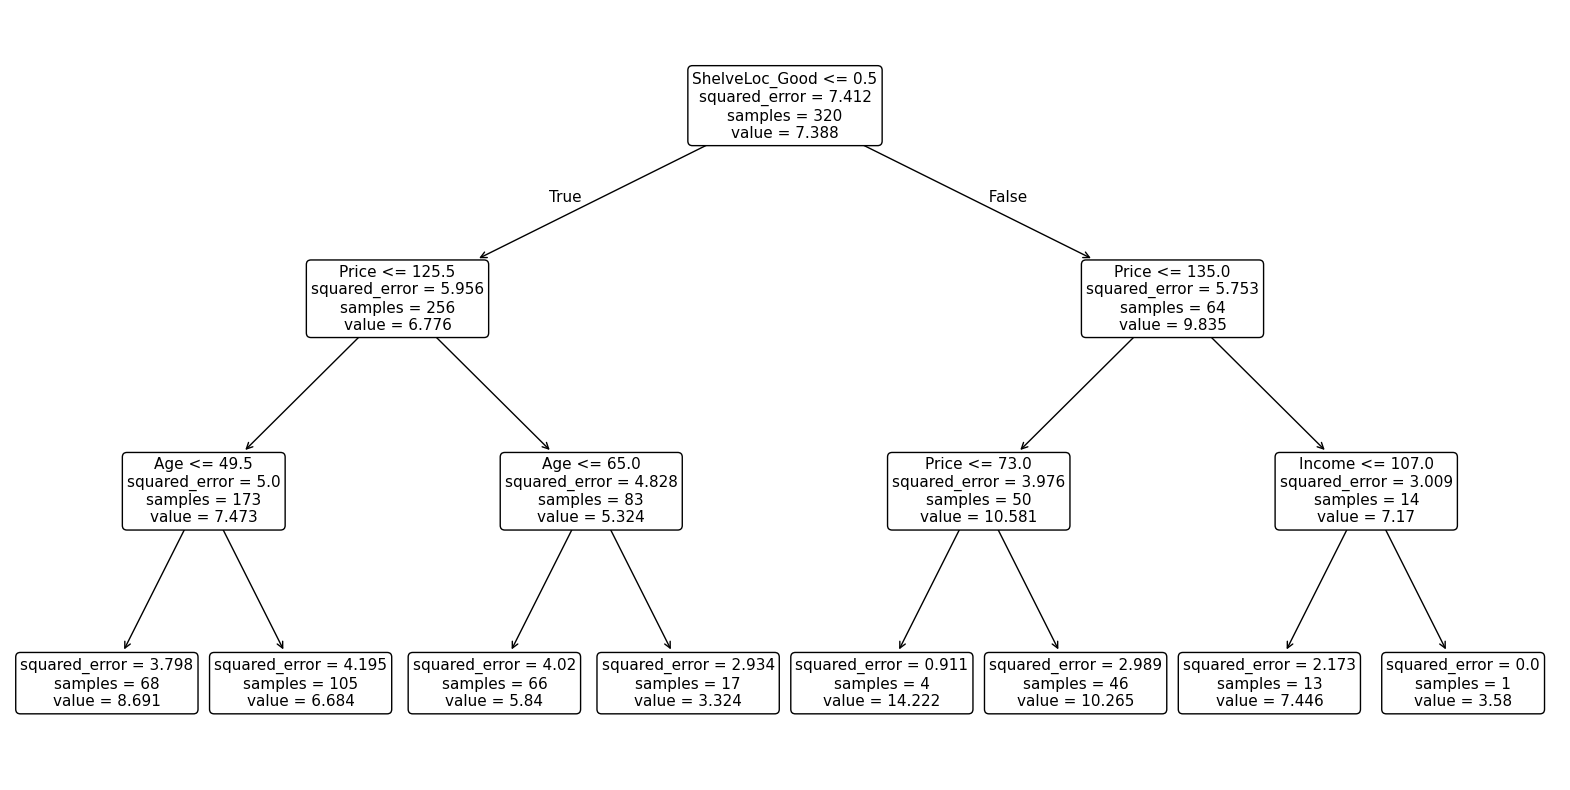

In [20]:

# Initialize and fit the regression tree model
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 10))
plot_tree(reg_tree, feature_names=X.columns, rounded=True)
plt.show()


For ShelveLoc_Good < 0.5, price less than 125.5 and age less than 49.5, sales is predicted to be 8.691. If ShelveLoc_Good < 0.5, the price is less than 125.5 but the customer's age is greater than 49.5, sales is predicted to be 6.684. 

For ShelveLoc_Good < 0.5, price greater than 125.5 and age less than 65, sales is predicted to be 5.84. If ShelveLoc_Good < 0.5, the price is greater than 125.5 but the customer's age is greater than 65, sales is predicted to be 3.324. 

For ShelveLoc_Good >0.5, price less than 73.0, sales is predicted to be 14.222. If ShelveLoc_Good >0.5, but the price is between 73 and 135.0, sales is predicted to be 10.265. 

For ShelveLoc_Good >0.5, price greater than 135.0, and income is less than 107.0, sales is predicted to be 7.446. If ShelveLoc_Good > 0.5, the price is greater than 135.0 but income is greater than 107.0, sales is predicted to be 3.58. 

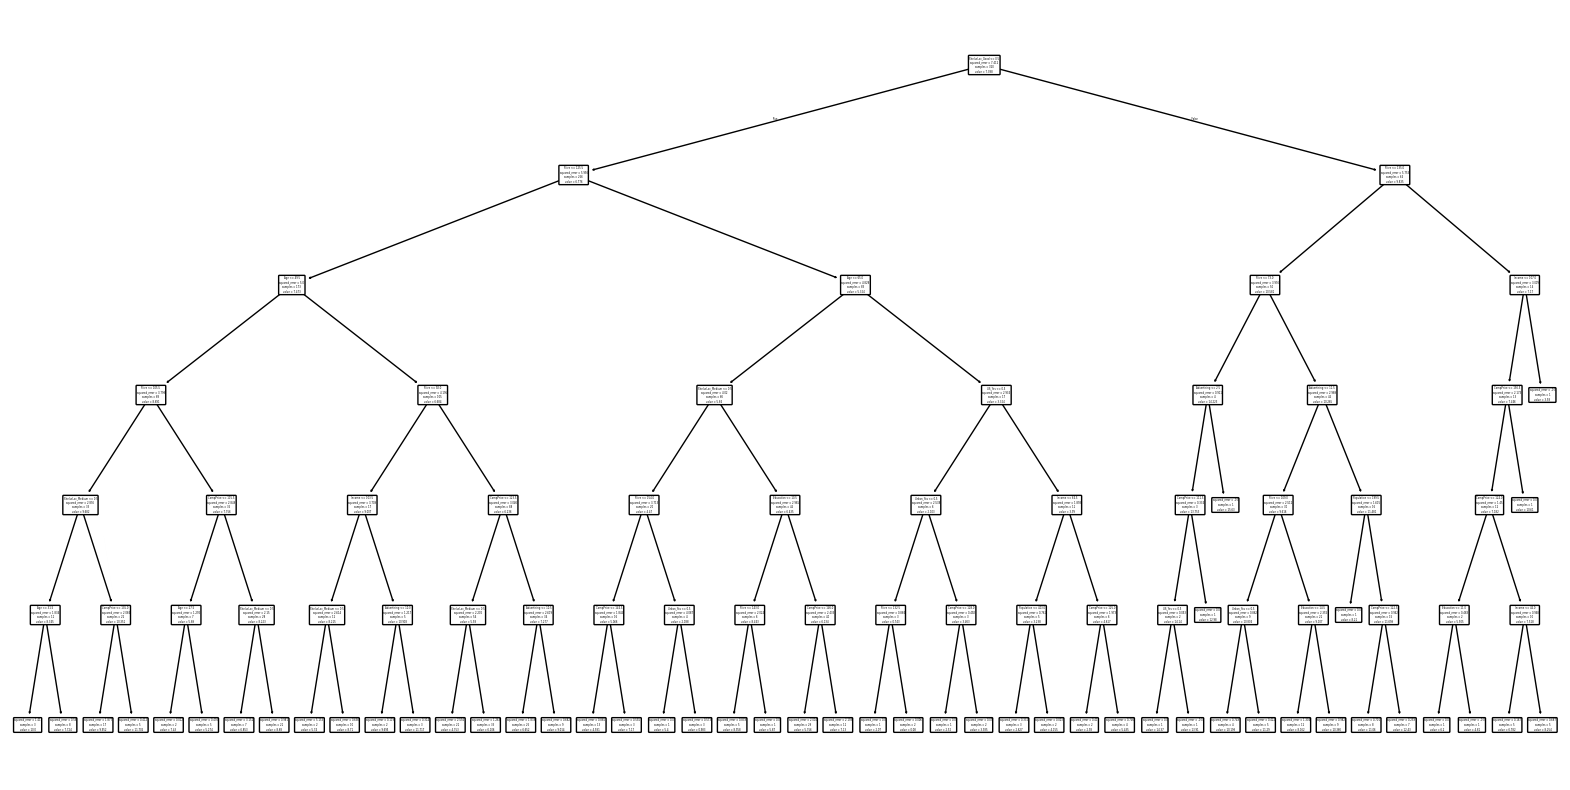

Optimal max_depth: 6
Test MSE for Pruned Regression Tree: 5.292
Pruning the tree reduces the test MSE from 6.179 to 5.292


In [21]:
# Part (c)

from sklearn.model_selection import GridSearchCV

# Set up the parameter grid for max_depth (tree depth)
param_grid = {'max_depth': range(1, 20)}

# Use GridSearchCV to find the best max_depth
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best tree depth and fit a pruned tree
best_depth = grid_search.best_params_['max_depth']
pruned_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
pruned_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 10))
plot_tree(pruned_tree, feature_names=X.columns, rounded=True)
plt.show()

# Predict on the test set and calculate MSE
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)

print(f"Optimal max_depth: {best_depth}")
print(f"Test MSE for Pruned Regression Tree: {mse_pruned:.3f}")

print(f"Pruning the tree reduces the test MSE from 6.179 to 5.292")

Test MSE for Bagging: 3.109
                  Importance
Price               0.309172
ShelveLoc_Good      0.198268
Age                 0.120176
CompPrice           0.092573
Advertising         0.082520
ShelveLoc_Medium    0.064372
Income              0.052222
Population          0.039527
Education           0.030512
Urban_Yes           0.006091
US_Yes              0.004567


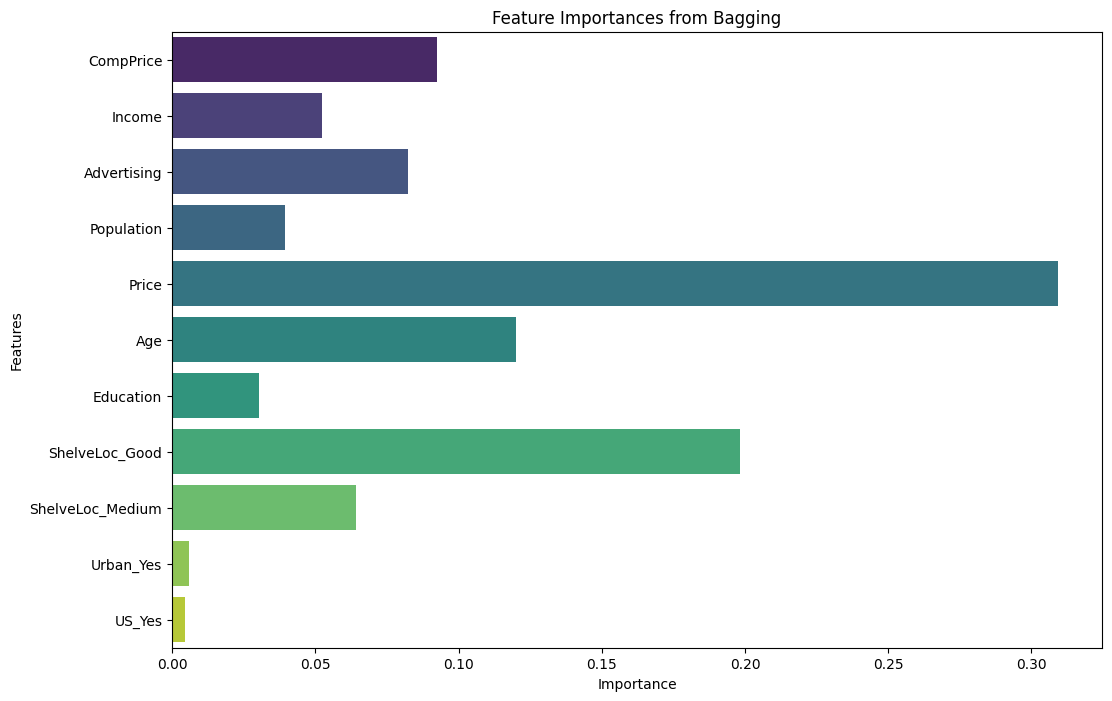

The three most important features in the Bagging Tree are Price ShelveLoc_Good and Age in that order


In [22]:
# Part (d)

model = MS(data.columns.drop('Sales'), intercept=False)
D = model.fit_transform(data)
feature_names = list(D.columns)
X = np.asarray(D)

# Initialize and fit a Bagging Regressor
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

# Predict on the test set and calculate MSE
y_pred_bagging = bagging.predict(X_test)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)

# Feature importance in bagging is usually derived from the base estimators
feature_importance_bagging = np.mean([
    tree.feature_importances_ for tree in bagging.estimators_
], axis=0)

print(f"Test MSE for Bagging: {mse_bagging:.3f}")
#print("Feature importances from Bagging:", feature_importance_bagging)

feature_imp = pd.DataFrame(
{'Importance':feature_importance_bagging},
index=feature_names)
print(feature_imp.sort_values(by='Importance', ascending=False))

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance_bagging, y=feature_names, palette='viridis')
plt.title('Feature Importances from Bagging')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

print(f"The three most important features in the Bagging Tree are Price ShelveLoc_Good and Age in that order")


Test MSE for Random Forest: 3.017
                  Importance
Price               0.308641
ShelveLoc_Good      0.198399
Age                 0.120021
CompPrice           0.092958
Advertising         0.082591
ShelveLoc_Medium    0.064645
Income              0.051968
Population          0.039585
Education           0.030814
Urban_Yes           0.005875
US_Yes              0.004504


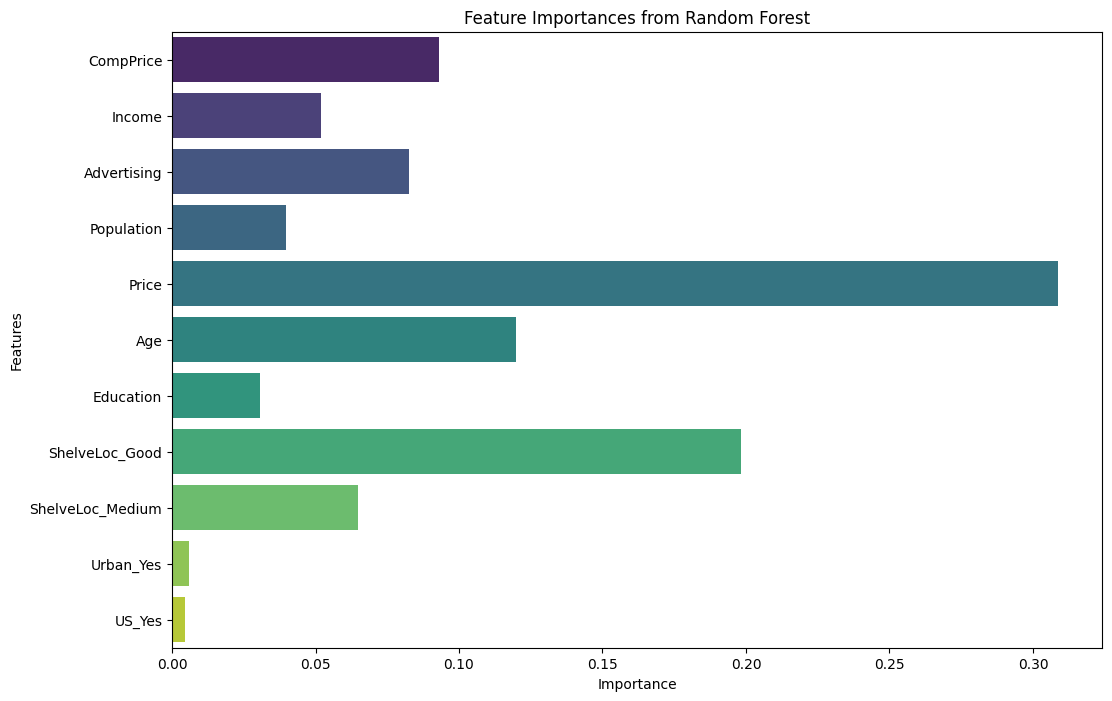

The three most important features in the Random Forest are Price ShelveLoc_Good and Age in that order


In [23]:
# Part (e)

# Initialize and fit a Random Forest Regressor
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Predict on the test set and calculate MSE
y_pred_rf = random_forest.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Get feature importances
feature_importance_rf = random_forest.feature_importances_

print(f"Test MSE for Random Forest: {mse_rf:.3f}")
#print("Feature importances from Random Forest:", feature_importance_rf)

feature_imp = pd.DataFrame(
{'Importance':feature_importance_rf},
index=feature_names)
print(feature_imp.sort_values(by='Importance', ascending=False))

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance_rf, y=feature_names, palette='viridis')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

print(f"The three most important features in the Random Forest are Price ShelveLoc_Good and Age in that order")

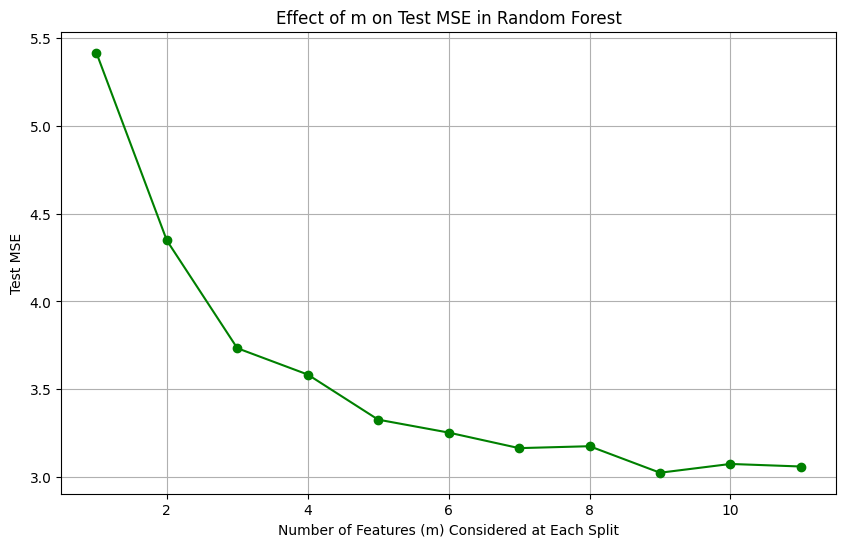

In [24]:
## List to store test MSE values for different m values
m_values = range(1, X_train.shape[1] + 1)  # m values from 1 to the number of features
test_mse_values = []

## Train a Random Forest with different max_features
for max_features in m_values:
    rf_model   = RandomForestRegressor(max_features=max_features, random_state=1, n_estimators=100)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred_rf)
    test_mse_values.append(test_mse)

## Plot the test MSE against m
plt.figure(figsize=(10, 6))
plt.plot(m_values, test_mse_values, marker='o', linestyle='-', color='g')
plt.xlabel('Number of Features (m) Considered at Each Split')
plt.ylabel('Test MSE')
plt.title('Effect of m on Test MSE in Random Forest')
plt.grid(True)
plt.show()

The m specifies the number of features to consider at each split. As m increases, the test error falls, gets to a minimum and eventually increases when m approaches the maximum number of features in the dataset. This is where the Randon Forest approach a Bagging Regression. The minimun m for this dataset is 9.

Test MSE for BART: 1.281


Text(0.5, 1.0, 'Scatteredplot of BRAT')

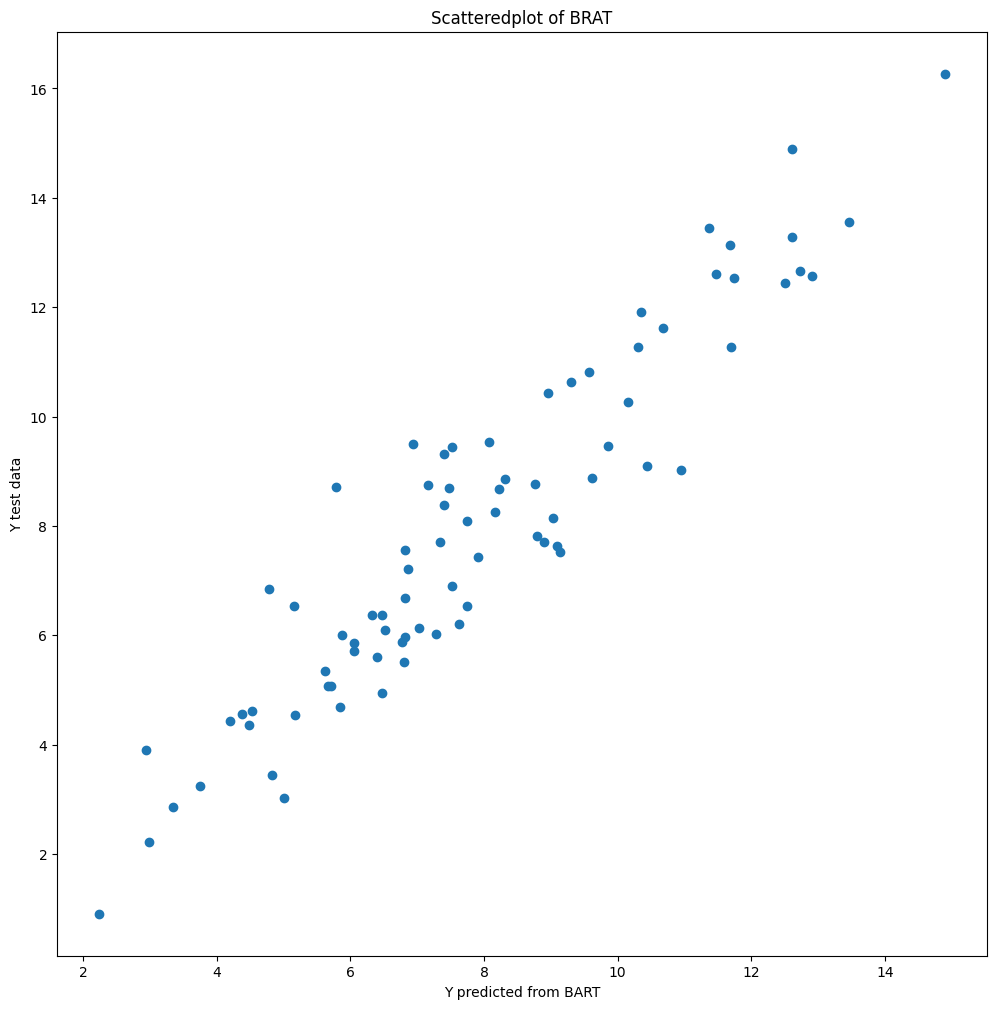

In [25]:
# Part (f)
# Ensure numeric types and handle missing values
X_train_encoded = X_train.astype(float).fillna(X_train.mean())
y_train_encoded = y_train.astype(float)

# Train BART model
bart_model = BART(random_state=1, num_trees=100, burnin=100, ndraw=500)
bart_model.fit(X_train_encoded.to_numpy(), y_train_encoded.to_numpy())

# Predict and calculate Test MSE
y_pred_bart = bart_model.predict(X_test.to_numpy())
mse_bart = mean_squared_error(y_test, y_pred_bart)
print('Test MSE for BART: {}'.format(np.around(mse_bart, 3)))


ax = plt.subplots(figsize=(12,12))[1]
ax.scatter(y_pred_bart , y_test)
plt.xlabel('Y predicted from BART')
plt.ylabel('Y test data')
plt.title('Scatteredplot of BRAT')


### Additional Questions

In [26]:
# Gradient Boosting
gb = GBR(n_estimators=100, random_state=1)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
test_mse_gb = mean_squared_error(y_test, y_pred_gb)
print("Test MSE for Gradient Boosting:", test_mse_gb)

Test MSE for Gradient Boosting: 2.033286590341155


In [27]:

# XGBoost
xgb = XGB(n_estimators=100, random_state=1, eval_metric='rmse')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
test_mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print("Test MSE for XGBoost:", test_mse_xgb)

Test MSE for XGBoost: 3.4228990488726594


In [28]:
warnings.filterwarnings('ignore')

# LightGBM
lgb = LGBMR(n_estimators=100, random_state=1, force_col_wise=True)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
test_mse_lgb = mean_squared_error(y_test, y_pred_lgb)
print("Test MSE for LightGBM:", test_mse_lgb)

[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 11
[LightGBM] [Info] Start training from score 7.388187
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [29]:

# Best boosting approach
best_boosting_mse = min(test_mse_gb, test_mse_xgb, test_mse_lgb)
print("Best Boosting Test MSE:", best_boosting_mse)

Best Boosting Test MSE: 2.033286590341155


The best boosting approach is the Gradient Boosting approach because it has the lowest test MSE.